# 01 — Data Understanding

**Owner:** Yasassri's lane — structure, dtypes, missingness, duplicates, target balance.

**Purpose:** establish what the raw sensor log contains and whether it is fit for modelling: what each column is, how the 54 rows with missing values behave, whether any rows are duplicated, and how rare the positive (protective stop) class is.

**Output:** a checked picture of the data (7,409 raw rows, 7,355 labelled rows, 278 stops = 3.78%), two figures (`fig01_missingness.png`, `fig01_target_balance.png`), and four logged decisions: drop the 54 unlabelled rows, no duplicate removal, cast the target to an integer type, and use PR-AUC as the primary metric.

**Viva questions to be ready for:** Why drop the 54 rows? Why is accuracy misleading at 3.78%?

Every important choice has a decision-log cell (what we decided, the evidence, the alternative considered, why it was rejected).

In [1]:
import sys
from pathlib import Path

# Jupyter's kernel CWD is notebooks/, so add the repo root to sys.path
# before importing anything from src/.
sys.path.append(str(Path.cwd().parent))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import RANDOM_STATE, FIGURES_DIR
from src.pipeline import load_data

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [3]:
df = load_data()
df.shape

(7409, 24)

In [4]:
df.head()

,Num,Timestamp,Current_J0,Temperature_T0,Current_J1,Temperature_J1,Current_J2,Temperature_J2,Current_J3,Temperature_J3,Current_J4,Temperature_J4,Current_J5,Temperature_J5,Speed_J0,Speed_J1,Speed_J2,Speed_J3,Speed_J4,Speed_J5,Tool_current,cycle,Robot_ProtectiveStop,grip_lost
0,1,2022-10-26 08:17:21.847000+00:00,0.109628,27.875,-2.024669,29.3750,-1.531442,29.3750,-0.998570,32.1250,-0.062540,32.2500,-0.152622,32.0000,2.955651e-01,-0.000490,0.001310,-0.132836,-0.007479,-0.152962,0.082732,1,0.0,False
1,2,2022-10-26 08:17:22.852000+00:00,0.595605,27.875,-2.278456,29.3125,-0.866556,29.4375,-0.206097,32.1875,-1.062762,32.2500,-0.260764,32.0000,-7.391485e-30,-0.000304,0.002185,0.001668,-0.000767,0.000417,0.505895,1,0.0,False
2,3,2022-10-26 08:17:23.857000+00:00,-0.229474,27.875,-2.800408,29.3125,-2.304336,29.4375,-0.351499,32.1250,-0.668869,32.3125,0.039071,32.0625,1.369386e-01,0.007795,-2.535874,0.379867,0.000455,-0.496856,0.079420,1,0.0,False
3,4,2022-10-26 08:17:24.863000+00:00,0.065053,27.875,-3.687768,29.3125,-1.217652,29.4375,-1.209115,32.1250,-0.819755,32.2500,0.153903,32.0000,-9.030032e-02,-0.004911,-0.009096,-0.384196,0.018411,0.425559,0.083325,1,0.0,False
4,5,2022-10-26 08:17:25.877000+00:00,0.884140,27.875,-2.938830,29.3750,-1.794076,29.4375,-2.356471,32.1875,-0.966427,32.3125,0.178998,32.0000,1.268088e-01,0.005567,0.001138,-0.353284,0.014994,0.180989,0.086379,1,0.0,False


## Column role table

Every column is classified by its role in the modelling pipeline, its raw dtype after loading, and a one-line description.
This table feeds directly into report section 4 (Data Understanding).

In [5]:
# Column metadata: role, dtype, description
# Roles: identifier | timestamp | sensor_feature | target | event_flag
column_meta = [
    ("Num",                   "identifier",     "int64",              "Sequential row index from the original log file"),
    ("Timestamp",             "timestamp",      "datetime64[ns,UTC]", "UTC wall-clock time of the reading (~1 s cadence)"),
    ("cycle",                 "identifier",     "int64",              "Cycle number grouping rows into discrete robot work cycles"),
    ("Current_J0",            "sensor_feature", "float64",            "Motor current (A) for joint 0 (base rotation)"),
    ("Current_J1",            "sensor_feature", "float64",            "Motor current (A) for joint 1 (shoulder)"),
    ("Current_J2",            "sensor_feature", "float64",            "Motor current (A) for joint 2 (elbow)"),
    ("Current_J3",            "sensor_feature", "float64",            "Motor current (A) for joint 3 (wrist 1)"),
    ("Current_J4",            "sensor_feature", "float64",            "Motor current (A) for joint 4 (wrist 2)"),
    ("Current_J5",            "sensor_feature", "float64",            "Motor current (A) for joint 5 (wrist 3)"),
    ("Temperature_T0",        "sensor_feature", "float64",            "Temperature (°C) at joint 0"),
    ("Temperature_J1",        "sensor_feature", "float64",            "Temperature (°C) at joint 1"),
    ("Temperature_J2",        "sensor_feature", "float64",            "Temperature (°C) at joint 2"),
    ("Temperature_J3",        "sensor_feature", "float64",            "Temperature (°C) at joint 3"),
    ("Temperature_J4",        "sensor_feature", "float64",            "Temperature (°C) at joint 4"),
    ("Temperature_J5",        "sensor_feature", "float64",            "Temperature (°C) at joint 5"),
    ("Speed_J0",              "sensor_feature", "float64",            "Joint angular speed (rad/s) for joint 0"),
    ("Speed_J1",              "sensor_feature", "float64",            "Joint angular speed (rad/s) for joint 1"),
    ("Speed_J2",              "sensor_feature", "float64",            "Joint angular speed (rad/s) for joint 2"),
    ("Speed_J3",              "sensor_feature", "float64",            "Joint angular speed (rad/s) for joint 3"),
    ("Speed_J4",              "sensor_feature", "float64",            "Joint angular speed (rad/s) for joint 4"),
    ("Speed_J5",              "sensor_feature", "float64",            "Joint angular speed (rad/s) for joint 5"),
    ("Tool_current",          "sensor_feature", "float64",            "Current (A) drawn by the end-effector tool"),
    ("Robot_ProtectiveStop",  "target",         "float64→int",        "1 = protective stop triggered, 0 = normal operation (the label to predict)"),
    ("grip_lost",             "event_flag",     "bool",               "True = gripper lost its object during this reading (correlated event, not a stop)"),
]

role_df = pd.DataFrame(column_meta, columns=["Column", "Role", "Dtype", "Description"])
role_df

,Column,Role,Dtype,Description
0,Num,identifier,int64,Sequential row index from the original log file
1,Timestamp,timestamp,"datetime64[ns,UTC]",UTC wall-clock time of the reading (~1 s cadence)
2,cycle,identifier,int64,Cycle number grouping rows into discrete robot...
3,Current_J0,sensor_feature,float64,Motor current (A) for joint 0 (base rotation)
4,Current_J1,sensor_feature,float64,Motor current (A) for joint 1 (shoulder)
5,Current_J2,sensor_feature,float64,Motor current (A) for joint 2 (elbow)
6,Current_J3,sensor_feature,float64,Motor current (A) for joint 3 (wrist 1)
7,Current_J4,sensor_feature,float64,Motor current (A) for joint 4 (wrist 2)
8,Current_J5,sensor_feature,float64,Motor current (A) for joint 5 (wrist 3)
9,Temperature_T0,sensor_feature,float64,Temperature (°C) at joint 0


## Dtype fixes

`Robot_ProtectiveStop` loaded as `float64` because the 54 missing rows forced pandas to use NaN (which requires float).
After we decide what to do with those rows (see Missingness section below), we cast it to a nullable integer (`Int8`) so it is
unambiguous as a binary label and consistent with the `bool` type of `grip_lost`.

In [6]:
# Before fix
print("Before:", df["Robot_ProtectiveStop"].dtype)

# Cast to nullable Int8 (preserves NaN rows before we drop them)
df["Robot_ProtectiveStop"] = df["Robot_ProtectiveStop"].astype("Int8")

print("After: ", df["Robot_ProtectiveStop"].dtype)
df[["Robot_ProtectiveStop", "grip_lost"]].dtypes

Before: float64
After:  Int8


Robot_ProtectiveStop    Int8
grip_lost               bool
dtype: object

## Missingness

The project plan states: *54 rows have missing values, all 54 are also missing the target, 46 missing every sensor.*
We confirm this finding and decide what to do with those rows.

In [7]:
# Missing value count per column
miss = df.isna().sum().rename("n_missing")
miss_pct = (miss / len(df) * 100).rename("pct_missing").round(2)
pd.concat([miss, miss_pct], axis=1)[miss > 0]

,n_missing,pct_missing
Current_J0,46,0.62
Temperature_T0,54,0.73
Current_J1,54,0.73
Temperature_J1,54,0.73
Current_J2,54,0.73
Temperature_J2,54,0.73
Current_J3,54,0.73
Temperature_J3,54,0.73
Current_J4,54,0.73
Temperature_J4,54,0.73


In [8]:
# Confirm the plan's three claims
missing_rows = df[df.isna().any(axis=1)]
n_missing_rows = len(missing_rows)

target_also_missing = missing_rows["Robot_ProtectiveStop"].isna().sum()

sensor_cols = [c for c in df.columns
               if c not in ("Num", "Timestamp", "cycle", "Robot_ProtectiveStop", "grip_lost")]
# 'all sensors missing' means ALL 21 sensor columns are NaN
all_sensors_missing = missing_rows[sensor_cols].isna().all(axis=1).sum()

print(f"Total rows with any NaN:           {n_missing_rows}  (plan says 54)")
print(f"Of those, target also missing:     {target_also_missing}  (plan says 54)")
print(f"Of those, ALL 21 sensors missing:  {all_sensors_missing}  (plan says 46)")
print()
# Note: Current_J0 has only 46 missing, not 54 — so 8 rows have some sensors but no target
partial_sensor_rows = n_missing_rows - all_sensors_missing
print(f"Rows with PARTIAL sensors missing: {partial_sensor_rows}  (these are the 8 remaining rows)")

Total rows with any NaN:           54  (plan says 54)
Of those, target also missing:     54  (plan says 54)
Of those, ALL 21 sensors missing:  46  (plan says 46)

Rows with PARTIAL sensors missing: 8  (these are the 8 remaining rows)


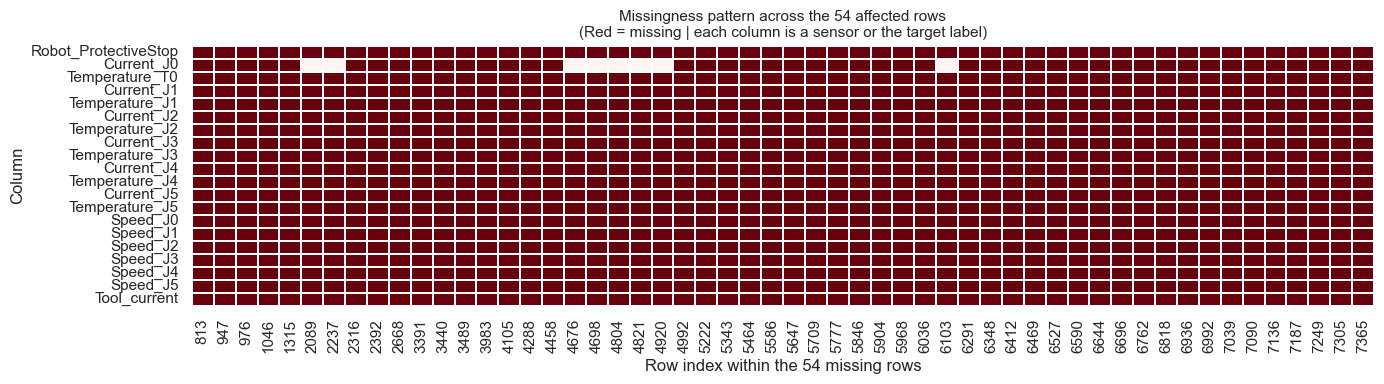

Saved → reports/figures/fig01_missingness.png


In [9]:
# Missingness heatmap — show only rows that have at least one NaN
fig, ax = plt.subplots(figsize=(14, 4))

# Build a boolean mask (True = missing)
miss_matrix = missing_rows[["Robot_ProtectiveStop"] + sensor_cols].isna()

sns.heatmap(
    miss_matrix.T,
    cbar=False,
    cmap="Reds",
    linewidths=0.3,
    ax=ax,
    yticklabels=True,
)
ax.set_title(
    f"Missingness pattern across the {n_missing_rows} affected rows\n"
    f"(Red = missing | each column is a sensor or the target label)",
    fontsize=11,
)
ax.set_xlabel("Row index within the 54 missing rows")
ax.set_ylabel("Column")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig01_missingness.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → reports/figures/fig01_missingness.png")

### Decision log — handling the 54 missing rows

**What we decided:** Drop all 54 rows with missing values.

**Evidence:**
- All 54 rows have a missing target (`Robot_ProtectiveStop = NaN`), so they cannot be used for supervised learning under any strategy.
- 46 of the 54 are missing all 21 sensor columns as well - there is no feature information to impute from.
- The remaining 8 rows have partial sensors but still no label, they are unusable as training examples.
- 54 rows is 0.73% of 7,409 - a negligible share of the dataset.

**Alternative considered:** Impute the sensor values for those 8 partially-missing rows and keep them as unlabelled data for semi-supervised learning.

**Why rejected:** Semi-supervised learning adds significant complexity and is out of scope for this project. The 8 rows represent 0.1% of the data; any information gain is immaterial. Dropping them is the simplest, most defensible choice and avoids introducing imputed values near the decision boundary.

In [10]:
# Apply the decision: drop all rows where the target is missing
df_clean = df.dropna(subset=["Robot_ProtectiveStop"]).copy()
df_clean["Robot_ProtectiveStop"] = df_clean["Robot_ProtectiveStop"].astype("int8")

print(f"Rows before drop: {len(df):,}")
print(f"Rows after drop:  {len(df_clean):,}  (dropped {len(df) - len(df_clean)} rows)")
print(f"Remaining NaNs:   {df_clean.isna().sum().sum()}")

Rows before drop: 7,409
Rows after drop:  7,355  (dropped 54 rows)
Remaining NaNs:   0


## Duplicate check

We check for two kinds of duplicates:
1. **Exact row duplicates** — all 24 column values identical.
2. **Duplicate timestamps** — same UTC second appearing more than once (would break temporal ordering in the split).

In [11]:
exact_dups = df_clean.duplicated().sum()
ts_dups    = df_clean.duplicated(subset=["Timestamp"]).sum()

print(f"Exact duplicate rows:      {exact_dups}")
print(f"Duplicate Timestamps:      {ts_dups}")

if exact_dups == 0 and ts_dups == 0:
    print("\n✓ No duplicates found — the dataset is temporally unique row-by-row.")

Exact duplicate rows:      0
Duplicate Timestamps:      0

✓ No duplicates found — the dataset is temporally unique row-by-row.


### Decision log — duplicates

**What we decided:** No action required.

**Evidence:** Zero exact duplicate rows and zero duplicate timestamps in the cleaned dataset (7,355 rows). Every row has a unique UTC timestamp at approximately 1-second cadence.

**Alternative considered:** Checking for near-duplicate rows (e.g., same timestamp ± 1 s, very similar sensor values).

**Why rejected:** The dataset logs from a single robot at ~1 Hz; sensor values naturally vary between consecutive seconds. Near-duplicate detection would require an arbitrary similarity threshold and is not warranted when exact duplicates are already zero.

## Target balance

We confirm the expected class distribution for `Robot_ProtectiveStop` and explain why it means accuracy is a misleading metric.

In [12]:
vc = df_clean["Robot_ProtectiveStop"].value_counts().sort_index()
total = len(df_clean)
pos = int(vc.get(1, 0))
neg = int(vc.get(0, 0))
pos_rate = pos / total * 100

print(f"Class 0 (normal):          {neg:,}  ({neg/total*100:.2f}%)")
print(f"Class 1 (protective stop): {pos:,}   ({pos_rate:.2f}%)")
print(f"Total (after dropping NaN rows): {total:,}")
print()
print(f"Imbalance ratio (majority:minority):  {neg/pos:.1f}:1")
print()
dummy_accuracy = neg / total * 100
print(f"A dummy classifier that always predicts 0 would score {dummy_accuracy:.2f}% accuracy.")
print("This is why we use PR-AUC as the primary metric, not accuracy.")

Class 0 (normal):          7,077  (96.22%)
Class 1 (protective stop): 278   (3.78%)
Total (after dropping NaN rows): 7,355

Imbalance ratio (majority:minority):  25.5:1

A dummy classifier that always predicts 0 would score 96.22% accuracy.
This is why we use PR-AUC as the primary metric, not accuracy.


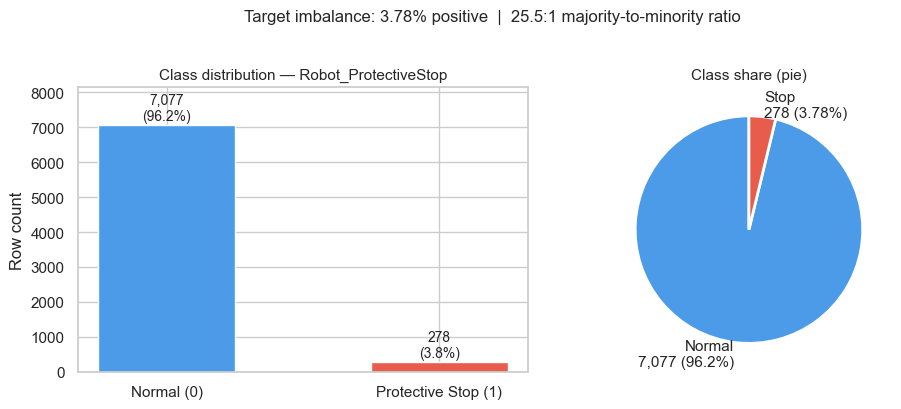

Saved → reports/figures/fig01_target_balance.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Left: bar chart ---
ax = axes[0]
bars = ax.bar(
    ["Normal (0)", "Protective Stop (1)"],
    [neg, pos],
    color=["#4C9BE8", "#E85C4C"],
    edgecolor="white",
    width=0.5,
)
for bar, n in zip(bars, [neg, pos]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{n:,}\n({n/total*100:.1f}%)",
        ha="center", va="bottom", fontsize=10,
    )
ax.set_title("Class distribution — Robot_ProtectiveStop", fontsize=11)
ax.set_ylabel("Row count")
ax.set_ylim(0, neg * 1.15)

# --- Right: pie chart ---
ax2 = axes[1]
ax2.pie(
    [neg, pos],
    labels=[f"Normal\n{neg:,} ({neg/total*100:.1f}%)",
            f"Stop\n{pos} ({pos_rate:.2f}%)"],
    colors=["#4C9BE8", "#E85C4C"],
    startangle=90,
    wedgeprops=dict(edgecolor="white", linewidth=2),
    autopct=None,
)
ax2.set_title("Class share (pie)", fontsize=11)

plt.suptitle(
    f"Target imbalance: {pos_rate:.2f}% positive  |  {neg/pos:.1f}:1 majority-to-minority ratio",
    fontsize=12, y=1.02,
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig01_target_balance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → reports/figures/fig01_target_balance.png")

### Decision log — primary metric choice

**What we decided:** Use **PR-AUC (average precision)** as the primary evaluation metric throughout the project, and report recall, precision, F1, balanced accuracy and ROC-AUC beside it.

**Evidence:**
- Only 278 of 7,355 rows (3.78%) are positive. The majority-to-minority ratio is 25.5:1.
- A dummy classifier that always predicts "normal" achieves 96.22% accuracy — yet it catches zero stops.
- PR-AUC summarises the precision–recall trade-off across all thresholds using only the stop class, so it is not flattered by the 96% of rows that are easy negatives.

**Alternative considered:** ROC-AUC as the sole metric.

**Why rejected:** ROC-AUC includes the true-negative rate. With 25 normal rows for every stop, a model can raise many false alarms and still have a small false-positive *rate*, so ROC-AUC can look strong while precision is poor (notebook 05: baseline XGBoost has ROC-AUC 0.91 but F1 0.36). PR-AUC reflects both missed stops and false alarms directly, so it is the more informative primary metric here. ROC-AUC is still reported alongside.

## Summary — Decision log

| # | Decision | Evidence | Alternative | Why rejected |
|---|----------|----------|-------------|---------------|
| 1 | Drop all 54 rows with missing target | All 54 have `Robot_ProtectiveStop = NaN`; 46 also have every sensor missing; only 0.73% of data | Impute the 8 partially-missing rows and use as unlabelled data | Semi-supervised out of scope; 0.1% information gain is immaterial |
| 2 | No duplicate removal needed | 0 exact duplicate rows, 0 duplicate timestamps in 7,355 rows | Near-duplicate detection with similarity threshold | No exact duplicates found; arbitrary threshold not warranted |
| 3 | Cast `Robot_ProtectiveStop` from float64 to Int8 | Column is binary (0/1); float was forced by NaN rows before dropping | Keep as float64 | Int8 is semantically correct for a binary label and saves memory |
| 4 | Use PR-AUC as primary metric | 3.78% positive rate; dummy-always-0 gets 96.22% accuracy yet catches no stops | ROC-AUC as sole metric | ROC-AUC counts the abundant true negatives, so it can stay high while precision is poor; PR-AUC uses only the stop class |